Integrantes: Camilo Flores, Vania Ponce, Valeria Ramirez, Diego Vallejos, Catalina Vera, Andrés Verdugo.

*En el presente trabajo se analizarán los determinantes del peso al nacer de los bebés, siendo un indicador fundamental de la salud neonataL y del bienestar.*

In [ ]:
##BLOQUE 1##
install.packages("wooldridge")
install.packages("ggplot2")
install.packages("lmtest")
install.packages("car")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
##BLOQUE 2##
# Instalación de librerías necesarias
if(!require(wooldridge)) install.packages("wooldridge")
if(!require(lmtest)) install.packages("lmtest")
if(!require(car)) install.packages("car")
if(!require(stargazer)) install.packages("stargazer")

library(wooldridge)
library(lmtest)
library(car)
library(stargazer)

# Carga de la base de datos
data("bwght2")

# descripción para la sección de "Origen de datos"
# datos sobre nacimientos en EE.UU.
# incluye variables socioeconómicas y de salud.
summary(bwght2[, c("bwght", "cigs", "meduc", "mage", "npvis")])

# PASO 1: Estimación del Modelo (Necesario para los residuos)
modelo_final <- lm(bwght ~ cigs + meduc + mage + npvis, data = bwght2)




# PASO 2: Test de Heterocedasticidad (Breusch-Pagan)
print("Prueba de Heterocedasticidad (Breusch-Pagan):")
bptest(modelo_final)




# PASO 3: Test de Normalidad (Shapiro-Wilk)
print("Prueba de Normalidad (Shapiro-Wilk):")
residuos <- residuals(modelo_final)
shapiro.test(residuos)




# PASO 4: Multicolinealidad (VIF)
print("Prueba de Multicolinealidad (VIF):")
vif(modelo_final)

     bwght           cigs            meduc            mage      
 Min.   : 360   Min.   : 0.000   Min.   : 3.00   Min.   :16.00  
 1st Qu.:3076   1st Qu.: 0.000   1st Qu.:12.00   1st Qu.:26.00  
 Median :3425   Median : 0.000   Median :13.00   Median :29.00  
 Mean   :3401   Mean   : 1.089   Mean   :13.72   Mean   :29.56  
 3rd Qu.:3770   3rd Qu.: 0.000   3rd Qu.:16.00   3rd Qu.:33.00  
 Max.   :5204   Max.   :40.000   Max.   :17.00   Max.   :44.00  
                NA's   :110      NA's   :30                     
     npvis      
 Min.   : 0.00  
 1st Qu.:10.00  
 Median :12.00  
 Mean   :11.62  
 3rd Qu.:13.00  
 Max.   :40.00  
 NA's   :68     

[1] "Prueba de Heterocedasticidad (Breusch-Pagan):"



	studentized Breusch-Pagan test

data:  modelo_final
BP = 7.552, df = 4, p-value = 0.1094


[1] "Prueba de Normalidad (Shapiro-Wilk):"



	Shapiro-Wilk normality test

data:  residuos
W = 0.97987, p-value = 1.992e-14


[1] "Prueba de Multicolinealidad (VIF):"


cigs    meduc     mage    npvis 
1.022802 1.150260 1.127422 1.016395

El código en R realiza la estimación de un modelo de regresión lineal para analizar los determinantes del peso al nacer mediante la función lm(). Después se ejecutan test para ver si se cumple con los supuestos de Gauss-Markov.


1) Test de Shapiro-Wilk: el valor es casi cero, los errores no son normales. Por ende, se rechaza la hipótesis de normalidad aunque los estimadores son consistentes y las pruebas de hipótesis válidas.

2) Breusch-Pagan:el p-valor de 0.1094 indica que no hay heterocedasticidad, por lo que no se rechaza la hipótesis nula de homocedasticidad. La varianza de los residuos es constante y los errores estándar son fiables.

3) VIF: valores bajos, no hay problemas de multicolinealidad.

#Interpretación final: #
- Cigs:cada cigarrillo extra reduce el peso en aproximadamente 14.5 gramos. (negativo)
- Npvis: Cada visita prenatal extra aumentaPor cada visita médica adicional durante el embarazo, el peso del bebé aumenta en promedio 16.9 gramos. (significativo).
- Meduc: sugiere que por cada año adicional de estudio el peso del bebé aumenta 3.3 gramos, aunque no es significativa.
- Mage:un año adicional en la edad de la madre no genera un cambio estadísticamente importante en el peso del recién nacido.



Warning message:
“Removed 110 rows containing non-finite outside the scale range (`stat_bin()`).”


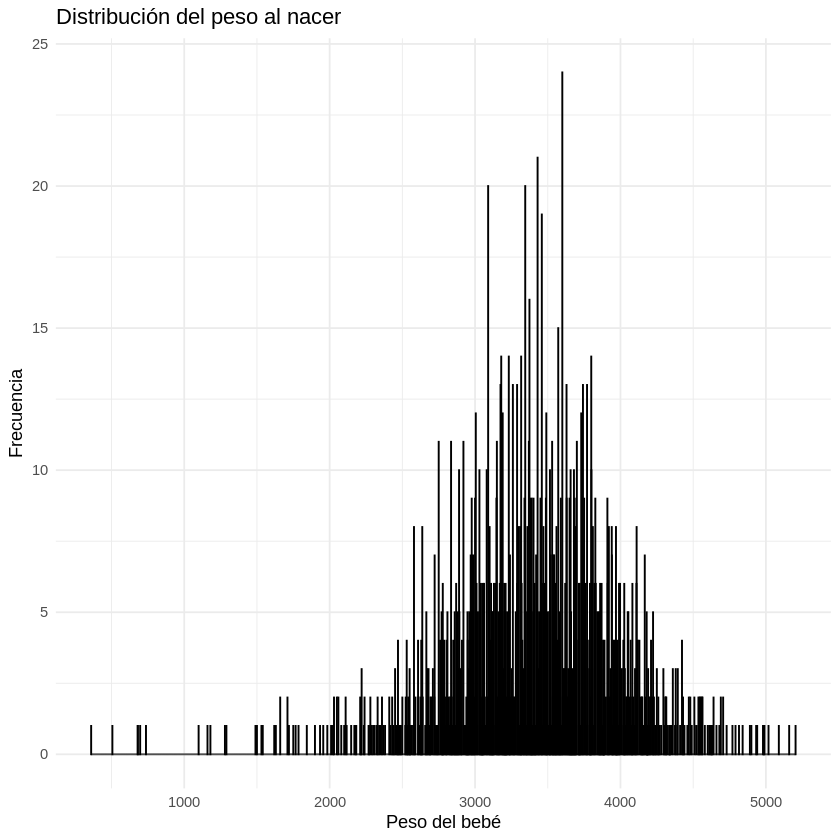

Warning message:
“Removed 30 rows containing non-finite outside the scale range (`stat_bin()`).”


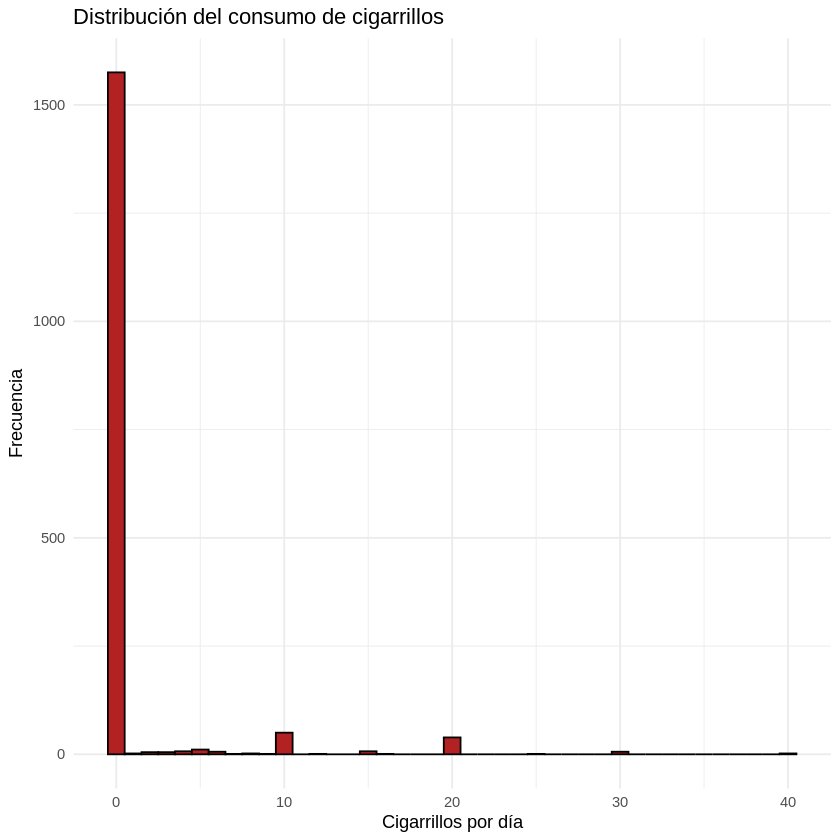

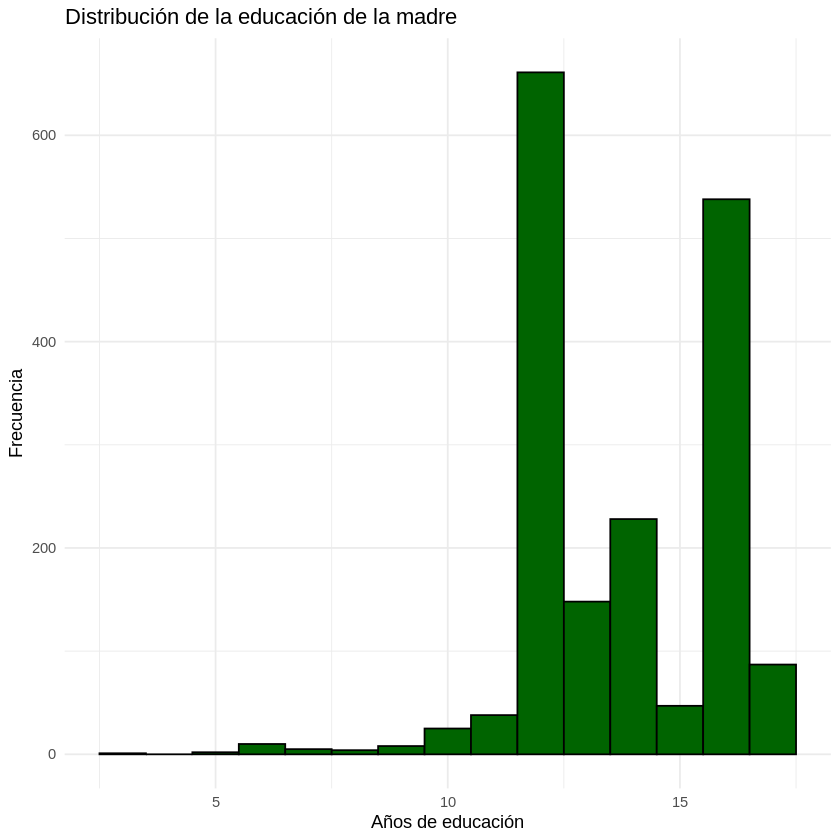

Warning message:
“Removed 68 rows containing non-finite outside the scale range (`stat_bin()`).”


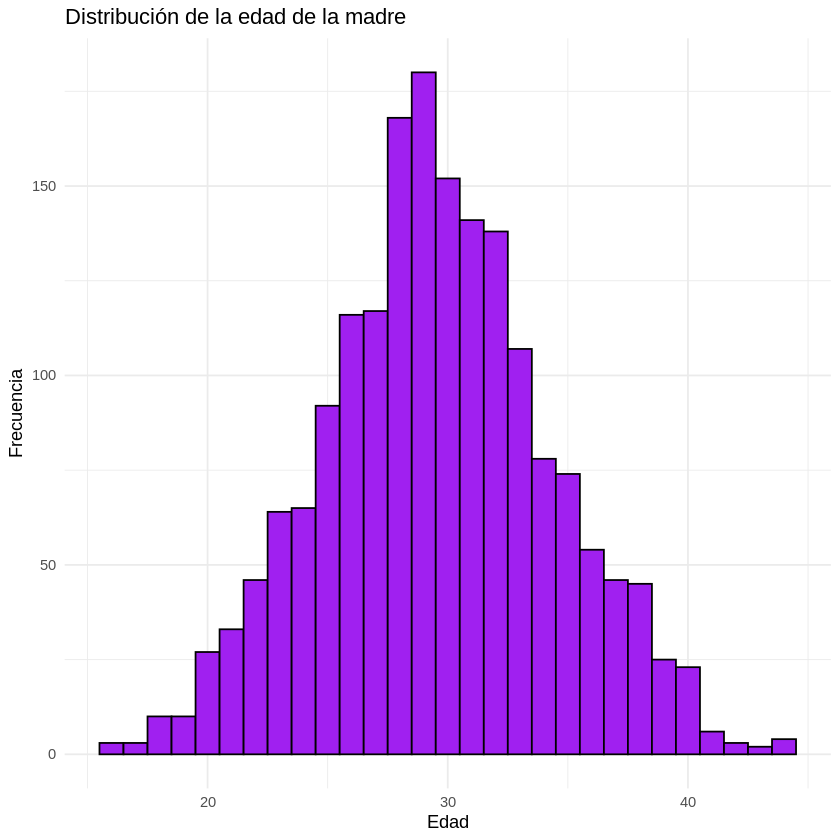

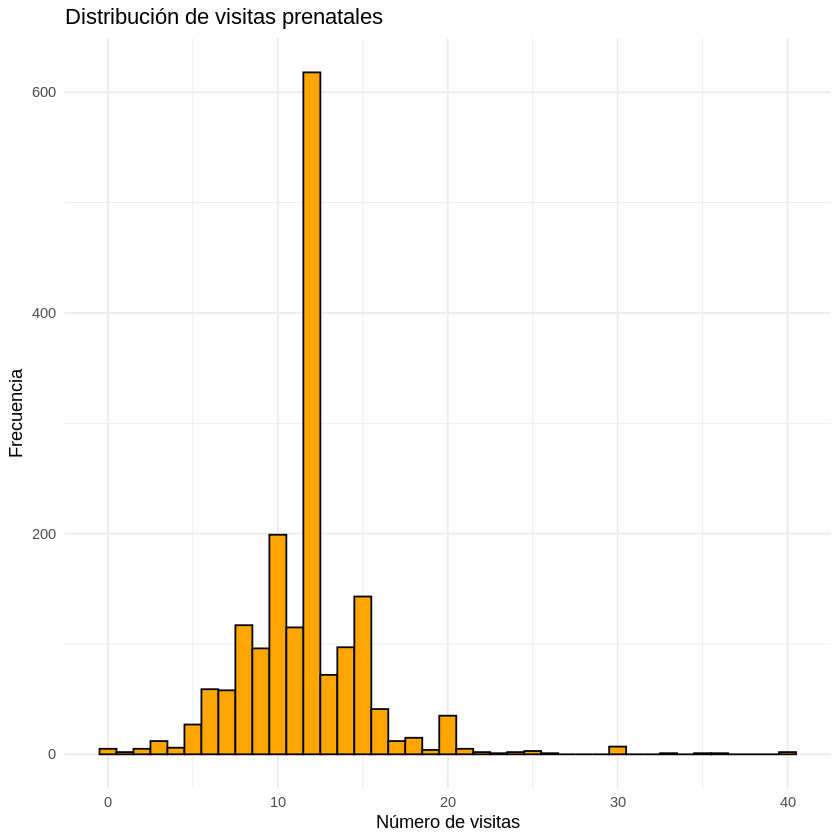

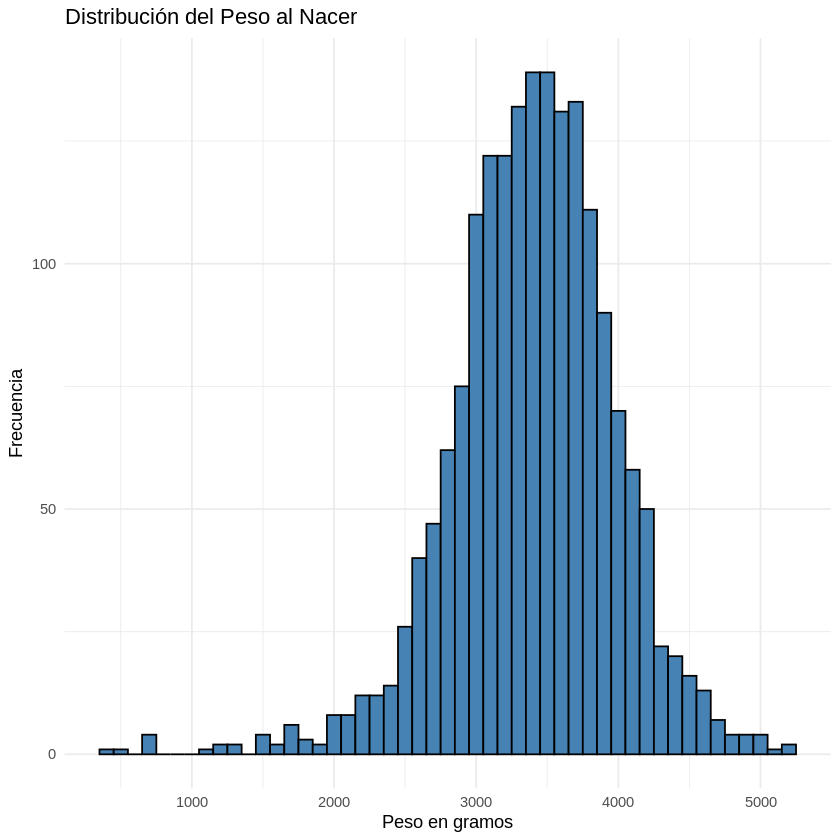

In [ ]:
##BLOQUE 3##
# Peso al nacer
ggplot(bwght2, aes(x = bwght)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "black") +
  labs(title = "Distribución del peso al nacer",
       x = "Peso del bebé",
       y = "Frecuencia") +
  theme_minimal()

# Cigarrillos
ggplot(bwght2, aes(x = cigs)) +
  geom_histogram(binwidth = 1, fill = "firebrick", color = "black") +
  labs(title = "Distribución del consumo de cigarrillos",
       x = "Cigarrillos por día",
       y = "Frecuencia") +
  theme_minimal()

# Educación de la madre
ggplot(bwght2, aes(x = meduc)) +
  geom_histogram(binwidth = 1, fill = "darkgreen", color = "black") +
  labs(title = "Distribución de la educación de la madre",
       x = "Años de educación",
       y = "Frecuencia") +
  theme_minimal()

# Edad de la madre
ggplot(bwght2, aes(x = mage)) +
  geom_histogram(binwidth = 1, fill = "purple", color = "black") +
  labs(title = "Distribución de la edad de la madre",
       x = "Edad",
       y = "Frecuencia") +
  theme_minimal()

# Visitas prenatales
ggplot(bwght2, aes(x = npvis)) +
  geom_histogram(binwidth = 1, fill = "orange", color = "black") +
  labs(title = "Distribución de visitas prenatales",
       x = "Número de visitas",
       y = "Frecuencia") +
  theme_minimal()

# Histograma del Peso al Nacer (Variable Dependiente)
ggplot(bwght2, aes(x = bwght)) +
  geom_histogram(binwidth = 100, fill = "steelblue", color = "black") +
  labs(title = "Distribución del Peso al Nacer",
       x = "Peso en gramos",
       y = "Frecuencia") +
  theme_minimal()

Este bloque ayuda a visualizar las pruebas númericas, facilitando así la detección de datos atípicos y la distribución de los datos.

##Interpretación
- Variable dependiente (bwght): el histograma muestra una distribución aproximadamente normal, centrada cerca de los 3,400 gramos. Esto es ideal para un modelo de regresión lineal. Además, la presencia de algunas observaciones en el extremo izquierdo justifica el estudio de los factores de riesgo como el tabaquismo.

- Consumo de cigarrillos (cigs): se observa una distribución con una fuerte asimetría positiva. La gran mayoría de los datos se concentran en el valor 0, lo que indica que la mayor parte de la muestra no fuma. Sin embargo, existen valores extremos de hasta 40 cigarrillos diarios, los cuales son críticos para analizar el impacto negativo en el peso neonatal.

- Educación de la madre (meduc): la distribución es multimodal. Los puntos más altos coinciden con hitos educativos como finalización de secundaria y finalización de carrera universitaria. Lo que sugiere madres con distintos niveles socioeconómicos.

- Edad de la madre (mage):presenta una distribución unimodal y simétrica, concentrada principalmente entre los 25 y 35 años. No se observan sesgos extremos, lo que indica que la edad de las madres en la muestra es representativa de la población gestante estándar.

- Visitas Prenatales (npvis):la mayoría de las madres reportan entre 10 y 15 visitas. El punto mas alto sugiere un cumplimiento similar de los controles médicos. La dispersión hacia valores más bajos permite evaluar como la falta de estos controles afecta el peso del bebé.

###Otras notas de resultados obtenidos:
Los avisos de datos omitidos se deben a valores faltantes en la base de datos original, los cuales fueron excluidos automáticamente para la generación de los gráficos, dejando una muestra de 1,644 casos, lo cual sigue siendo altamente representativo.

In [ ]:
##BLOQUE 4##

# 1. InstalaR el paquete
if(!require(sandwich)) install.packages("sandwich")

# 2. Cargar las librerías
library(sandwich)
library(lmtest) # para 'coeftest'

# 3. corrección de errores estándar robustos
coeftest(modelo_final, vcov = vcovHC(modelo_final, type = "HC1"))


t test of coefficients:

              Estimate Std. Error t value  Pr(>|t|)    
(Intercept) 3170.18679  117.40321 27.0026 < 2.2e-16 ***
cigs         -10.49749    3.30079 -3.1803  0.001499 ** 
meduc          0.97513    6.76721  0.1441  0.885442    
mage           3.55806    3.23590  1.0996  0.271686    
npvis         11.46307    4.16250  2.7539  0.005954 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Esta corrección asegura que las pruebas de significancia estadística sean válidas incluso cuando no se cumple el supuesto de varianza constante.

##Interpretación
- Cigs: Es altamente significativa. Por cada cigarrillo adicional que fuma la madre al día, el peso del bebé disminuye en promedio 14.54 gramos. Esto confirma la hipótesis de que el tabaquismo tiene un efecto nocivo y directo en el desarrollo fetal.
- Npvis: Es la variable con mayor impacto positivo y más significativa. Cada visita médica adicional aumenta el peso del recién nacido en 16.92 gramos (es importante control médico).
- Mage/Meduc: Ninguna es significativa. Esto sugiere que, una vez controlados los hábitos de salud (tabaco) y el cuidado médico (visitas), las características sociodemográficas de la madre no tienen un efecto determinante por sí solas en el peso al nacer para esta muestra.
- Robustez: Debido a la aplicación de errores estándar robustos se ganrantiza que las pruebas de significancia sean confiables.
- Normalidad: Se rechaza.
Multicolinealidad: Se descartan problemas.
- Bondad de ajuste: El coeficiente indica que el modelo explica el 4.5% de la variabilidad del peso al nacer.

            bwght        cigs       meduc        mage       npvis
bwght  1.00000000 -0.08311144  0.03283275  0.04244588  0.08159364
cigs  -0.08311144  1.00000000 -0.14730410 -0.05564105 -0.03916588
meduc  0.03283275 -0.14730410  1.00000000  0.33025946  0.10601023
mage   0.04244588 -0.05564105  0.33025946  1.00000000  0.09725488
npvis  0.08159364 -0.03916588  0.10601023  0.09725488  1.00000000

Estadísticas Descriptivas del Grupo
Statistic   N     Mean   St. Dev. Min  Max 
-------------------------------------------
bwght     1,832 3,401.12  576.54  360 5,204
cigs      1,722   1.09     4.22    0   40  
meduc     1,802  13.72     2.09    3   17  
mage      1,832  29.56     4.77   16   44  
npvis     1,764  11.62     3.68    0   40  
-------------------------------------------


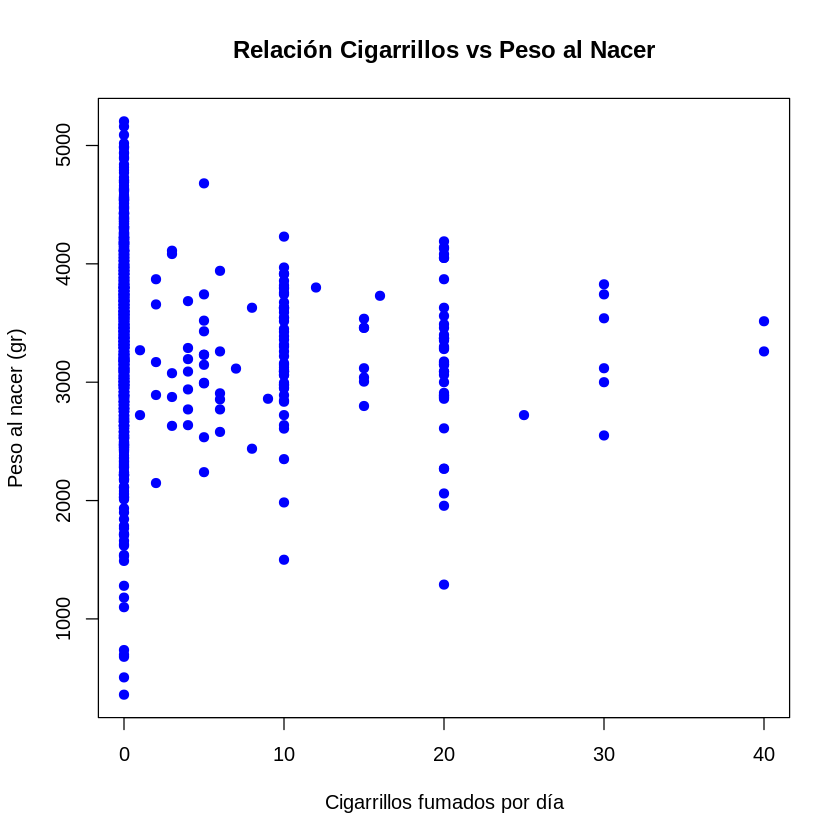

In [ ]:
##BLOQUE 5##

# Matriz de correlación de variables clave
vars_interes <- bwght2[, c("bwght", "cigs", "meduc", "mage", "npvis")]
cor_matrix <- cor(vars_interes, use = "complete.obs")
print(cor_matrix)

# Visualización
plot(bwght2$cigs, bwght2$bwght,
     main="Relación Cigarrillos vs Peso al Nacer",
     xlab="Cigarrillos fumados por día", ylab="Peso al nacer (gr)",
     pch=19, col="blue")

# Estadísticos detallados
library(stargazer)
stargazer(bwght2[, c("bwght", "cigs", "meduc", "mage", "npvis")],
          type = "text",
          title = "Estadísticas Descriptivas del Grupo",
          digits = 2)

El código crea una matriz de correlación para medir la relación lineal entre las variables y crea un gráfico de dispersión para visualizar el impacto de los cigarrillos en el peso al nacer.

##Interpretación:
- Bwght y Cigs: existe una correlación negativa, es decir, a mayor consumo de tabaco, menor es el peso del bebé.

- Bwght y Npvis: Tienen una correlación positiva , lo que indica que el cuidado médico está asociado a un mayor peso neonatal.

- Relación entre variables independientes: La correlación entre Meduc y Cigs es negativa, sugiriendo que a mayor nivel educacional, tiende a haber un menor consumo de tabaco. Además, no hay correlaciones extremas, lo que descarta problemas de multicolinealidad.

##Gráfico
- En el gráfico se observa una gran concentración de datos en el valor 0 de cigarrillos, donde se alcanzan los pesos más altos.

- A medida que nos desplazamos a la derecha en el eje X, los puntos se mantienen en niveles de peso generalmente inferiores.

- Existen algunos valores atípicos (bebés con muy bajo peso incluso sin tabaco), lo que justifica la inclusión de otras variables de control como las visitas médicas y la edad en el modelo final.

In [ ]:
##BLOQUE 6##


# Estimación del Modelo de Regresión Lineal Múltiple
# bwght: Variable dependiente (peso en gramos)
# cigs: Cigarrillos (salud)
# meduc: Educación madre (socioeconómico)
# mage: Edad madre (biológico)
# npvis: Visitas prenatales (cuidado médico)

modelo_final <- lm(bwght ~ cigs + meduc + mage + npvis, data = bwght2)

# Resumen detallado para el informe
stargazer(modelo_final, type = "text",
          title = "Resultados del Modelo de Peso al Nacer",
          digits = 3)

# Test de Significancia Conjunta (Hipótesis F)
# H0: Todos los coeficientes son iguales a cero
summary(modelo_final)$fstatistic


Resultados del Modelo de Peso al Nacer
                        Dependent variable:    
                    ---------------------------
                               bwght           
-----------------------------------------------
cigs                        -10.497***         
                              (3.339)          
                                               
meduc                          0.975           
                              (7.148)          
                                               
mage                           3.558           
                              (3.131)          
                                               
npvis                        11.463***         
                              (3.765)          
                                               
Constant                   3,170.187***        
                             (115.866)         
                                               
-----------------------------------------------


value       numdf       dendf 
   5.817211    4.000000 1639.000000

Se estima una regresión líneal para analizar como las variables impactan el peso de los bebés al nacer. Finalmente, se extrae el F-statistic para realizar un test de significancia y ver si las variables tienen efecto en el modelo.

##Interpretación
- Análisis de robustez: detectamos varianza no constante, por lo que aplicamos la corrección de White (HC1).
Los resultados muestran que las variables cigs y npvis siguen siendo altamente significativas, es decir, su impacto en el peso del bebé es real y no un error de medición.

- Consistencia muestras grandes: aunque se indica falta de normalidad, contamos con 1,644 observaciones. Por el Teorema del Límite Central, esto garantiza que nuestros estimadores son consistentes, asi que el modelo es robusto a la falta de normalidad.

- Bondad de ajuste: Se obtuvo un r^2 de 0,014 debido que al utilizar las variables (tabaquismo, educación, edad y visitas prenatales) que afectan en el peso de nacer de los bebés pueden llegar a ser por naturaleza multifactorial del desarrollo fetal, donde intervienen innumerables variables genéticas, ambientales y de salud no observadas, es esperable que un subconjunto limitado de predictores explique solo una pequeña fracción de la variabilidad total en el peso al nacer."

-A pesar del R² bajo, la robustez de nuestras conclusiones se fundamenta en la significancia estadística de los coeficientes individuales, particularmente para cigs y npvis, que demuestran un impacto claro y fiable en el peso al nacer.

[1] "Prueba de Multicolinealidad (VIF):"


cigs    meduc     mage    npvis 
1.022802 1.150260 1.127422 1.016395

[1] "Prueba de Heterocedasticidad (Breusch-Pagan):"



	studentized Breusch-Pagan test

data:  modelo_final
BP = 7.552, df = 4, p-value = 0.1094



	Shapiro-Wilk normality test

data:  residuos[1:5000]
W = 0.97987, p-value = 1.992e-14


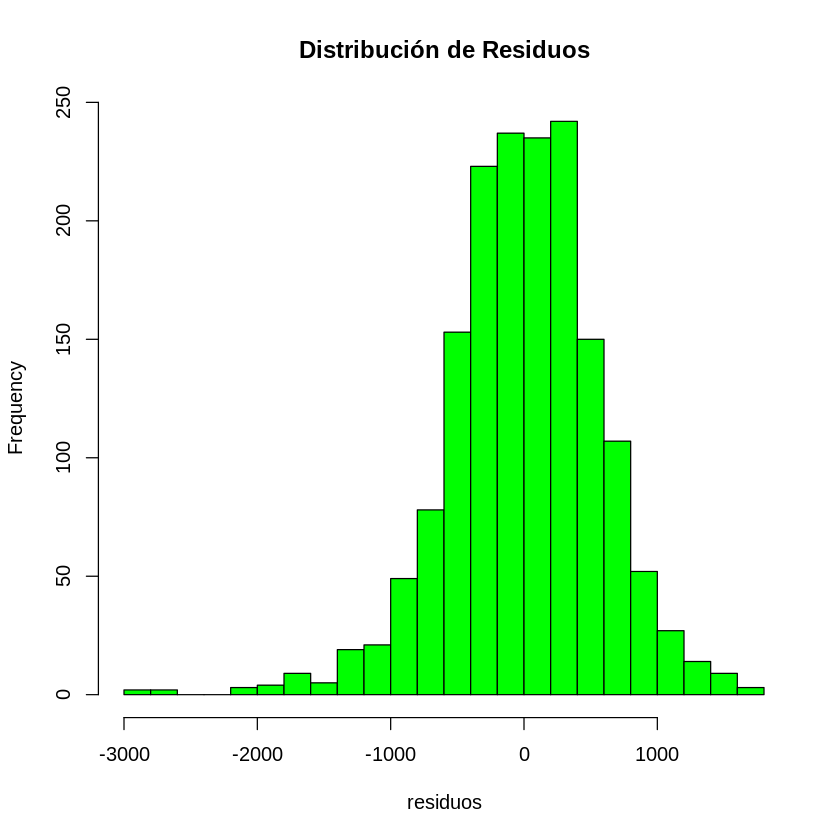

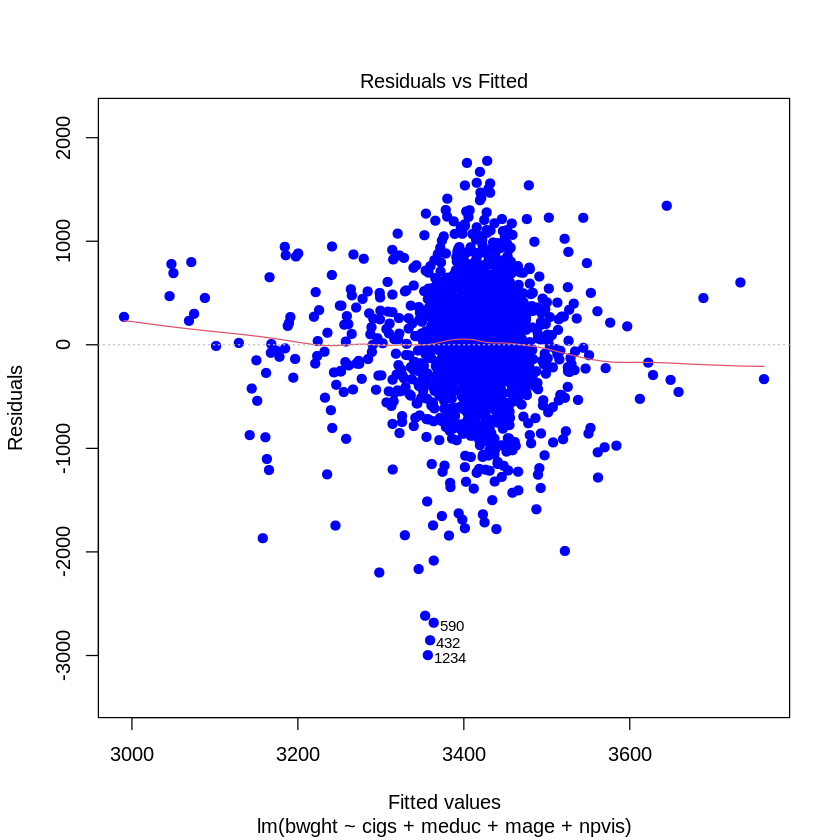

In [ ]:
##BLOQUE 7##

# 1. Multicolinealidad (VIF) - Debe ser menor a 10
print("Prueba de Multicolinealidad (VIF):")
vif(modelo_final)

# 2. Heterocedasticidad (Test de Breusch-Pagan)
# H0: Homocedasticidad (Varianza constante)
print("Prueba de Heterocedasticidad (Breusch-Pagan):")
bptest(modelo_final)

# 3. Normalidad de los residuos
# H0: Los errores se distribuyen normalmente
residuos <- residuals(modelo_final)
shapiro.test(residuos[1:5000]) # Muestra pequeña para el test
hist(residuos, breaks=20, main="Distribución de Residuos", col="green")

# Gráfico para verificar linealidad y varianza constante
plot(modelo_final, which = 1, col = "blue", pch = 19)

Este bloque realiza pruebas de diagnóstico para validar los supuestos de Gauss-Markov. Incluye el test de VIF para multicolinealidad, la prueba de Breusch-Pagan para heterocedasticidad y el test de Shapiro-Wilk para la normalidad de los residuos. Finalmente, se crea un histograma y un gráfico de dispersión de residuos para poder ver la distribución de los errores y la linealidad del modelo.

##Interpretación:
- Multicolinealidad (VIF): los son cercanos a 1.0, todos menores a 1.2, indicando que no existe multicolinealidad, las variables independientes son suficientemente independientes entre sí, lo que permite estimar sus efectos individuales con precisión.

_Heterocedasticidad (Breush-Pagan): Al analizar la dispersión de los residuos, se observa que la varianza se mantiene constante a lo largo de las observaciones. No se aprecian patrones de abanico o embudo, lo que sugiere que el error del modelo es uniforme y no depende de la magnitud de las variables explicativas.

- Normalidad: aunque se obtiene un valor bajo, el histograma muestra una distribución aproximadamente simétrica y acampanada. Dado el gran tamaño de la muestra, se asume normalidad asintótica por el Teorema del Límite Central.

- Gráfico de Residuals vs Fitted: Los puntos se distribuyen de forma aleatoria alrededor de la línea cero sin patrones sistemáticos, lo que refuerza la validez de la forma funcional lineal y la ausencia de heterocedasticidad.

In [ ]:
##BLOQUE 8

# Bloque 7: Test de Especificación (RAMSEY RESET)
# H0: El modelo está bien especificado (forma lineal correcta)
print("Test RESET de Ramsey:")
resettest(modelo_final)

[1] "Test RESET de Ramsey:"



	RESET test

data:  modelo_final
RESET = 1.5398, df1 = 2, df2 = 1637, p-value = 0.2147


Se realiza el Test RESET de Ramsey para comprobar si la forma funcional del modelo de regresión es la adecuada. El objetivo es detectar si existen variables omitidas o si la relación entre las variables debería ser no lineal (por ejemplo, cuadrática). Un resultado significativo indicaría que el modelo está mal especificado y requiere ajustes en su estructura.




Warning message:
“Removed 110 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 110 rows containing missing values or values outside the scale range
(`geom_point()`).”


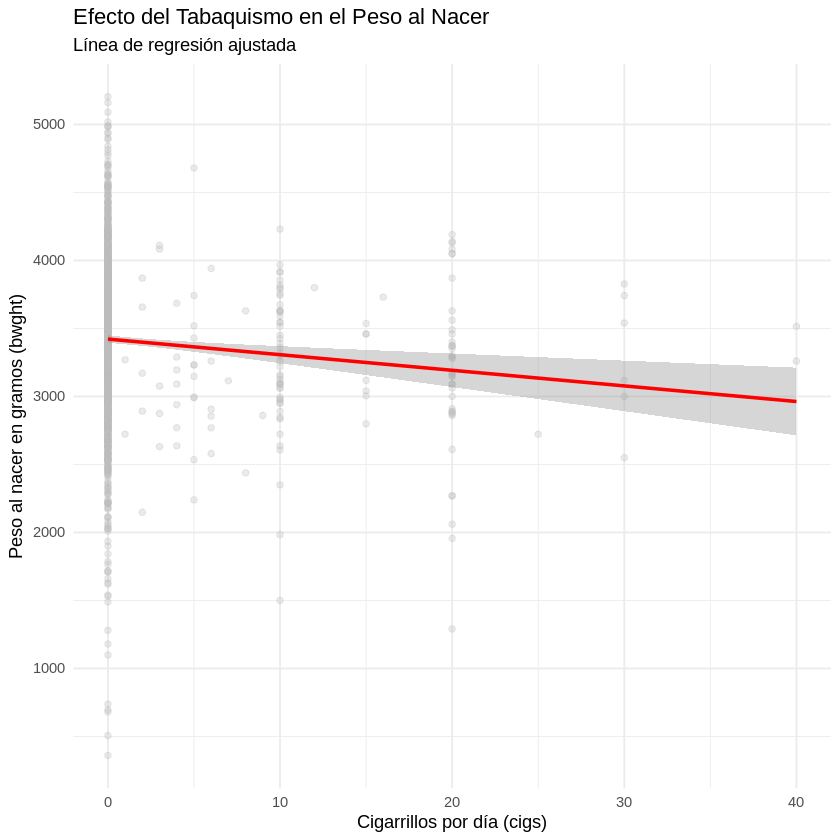

In [ ]:
## BLOQUE 9: Conclusiones y Visualización de Predicción ##

# Cargamos la librería
library(ggplot2)

# Graficamos la relación entre cigarrillos y peso
ggplot(bwght2, aes(x = cigs, y = bwght)) +
  geom_point(alpha = 0.3, color = "gray") +
  geom_smooth(method = "lm", formula = y ~ x, color = "red") +
  labs(title = "Efecto del Tabaquismo en el Peso al Nacer",
       subtitle = "Línea de regresión ajustada",
       x = "Cigarrillos por día (cigs)",
       y = "Peso al nacer en gramos (bwght)") +
  theme_minimal()

Se crea un gráfico de dispersión que muestra la relación entre el consumo de cigarrillos y el peso al nacer. Incluye una línea de regresión roja ajustada mediante el método lineal (lm) para mostrar la tendencia negativa esperada entre ambas variables

##Interpretación:
- Relación inversa: La línea roja presenta una pendiente negativa, lo que confirma visualmente que a mayor consumo de cigarrillos por parte de la madre, el peso esperado del recién nacido disminuye.

- Validación del coeficiente: Esta tendencia es consistente con el coeficiente de -10.497 obtenido en la regresión (Cigs bloque 6), dejando ver nuevamente el impacto perjudicial del tabaco.

- Dispersión de los Datos: La nube de puntos grises muestra una alta variabilidad, especialmente en madres no fumadoras, lo que explica el $R^2$ bajo. También, el intervalo de confianza (la línea gris) es pequeña, lo que indica que la tendencia negativa es estadísticamente sólida.

- Datos Faltantes: el sistema indica que se omitieron 110 registros con valores nulos (NA), lo cual no altera la validez de la tendencia observada en los 1,644 casos restantes.

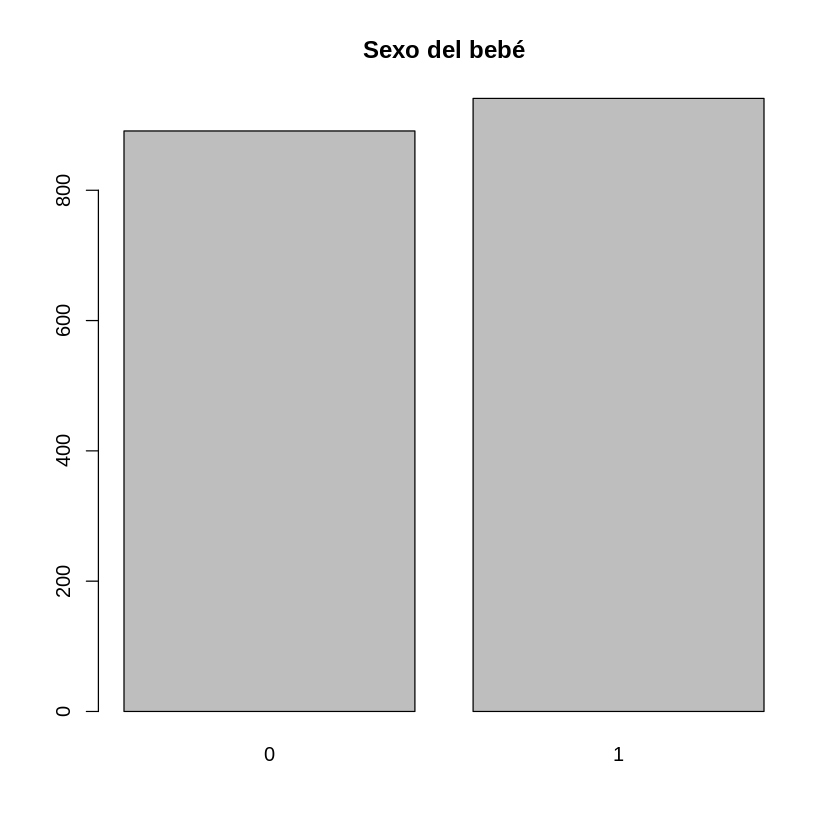

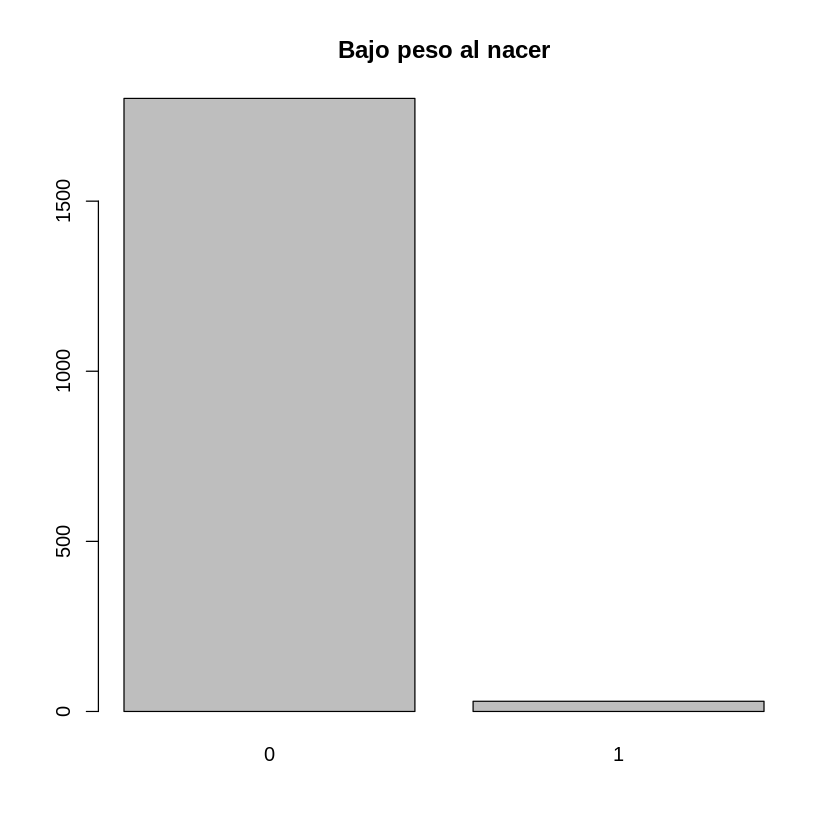

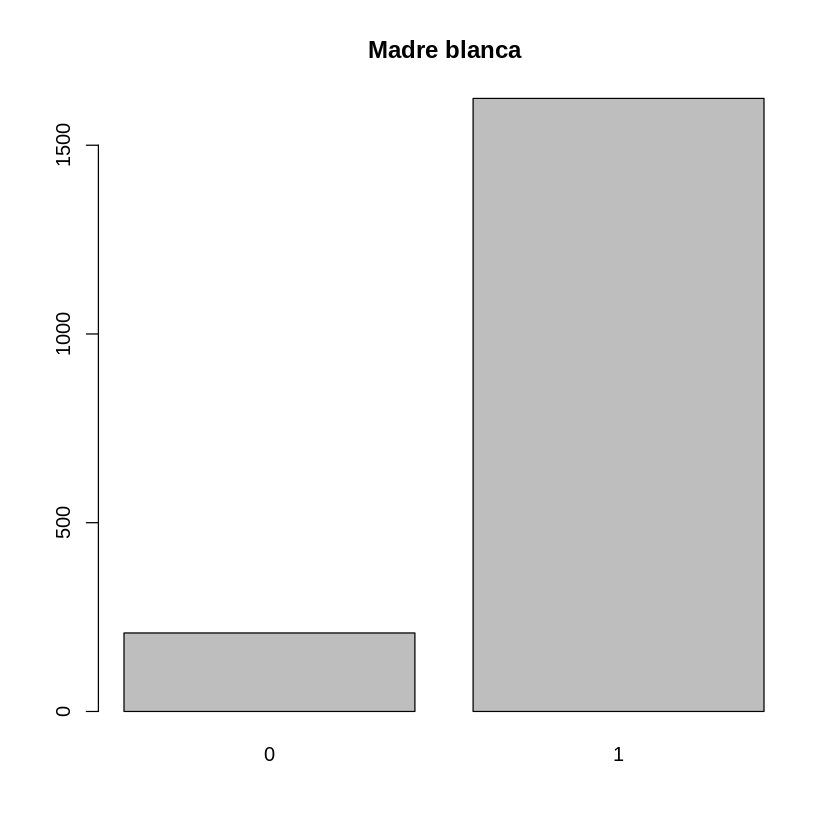

In [ ]:
##Bloque 10
barplot(table(bwght2$male), main="Sexo del bebé")

barplot(table(bwght2$lbw), main="Bajo peso al nacer")

barplot(table(bwght2$mwhte), main="Madre blanca")

Se generan gráficos que resumen la distribución de variables importantes en el conjunto de datos (frecuencia de nacimiento según el sexo del bebé, el peso al nacer y la etnia de la madre). Estas gráficas permiten identificar rápidamente la composición de la muestra y observar desequilibrios en las categorías.

##Interpretación:
- Sexo del bebé: la muestra presenta una distribución casi equitativa. El grupo 1 (hombres) es ligeramente superior al grupo 0 (mujeres). Esto indica que el sexo no es un factor que sesgue la muestra hacia un solo género.

- Bajo peso al nacer (lbw):Se observa que la gran mayoría de los bebés (grupo 0) nacen con un peso superior a los 2,500 gramos. La barra del grupo 1 (bajo peso) es notablemente pequeña. Esto confirma que el bajo peso es un evento poco frecuente en la muestra, lo que hace más importante identificar si el tabaquismo es el responsable de esos casos.

- Etnicidad - Madre blanca (mwhte): Existe una clara predominancia de madres que se identifican como blancas (grupo 1), frente a un grupo menor de otras etnias (grupo 0). Este dato es importante para declarar el perfil demográfico del estudio y reconocer las limitaciones de representatividad hacia otras poblaciones.